In [1]:
import pandas as pd
import json
import os
import matplotlib as mpl
from matplotlib import pyplot as plt
import requests
from io import StringIO as sio
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
import itertools
import re
import sys
import pprint
import statistics

module_dir = "/Users/monclalab1/Documents/scripts"
sys.path.append(module_dir)

import balticEdited as bt

In [2]:
def load_tree(filename):
    mytree, meta = bt.loadJSON(filename)
    return(mytree)

filename = 'auspice/h3nx_ha.json'
mytree = load_tree(filename)


Tree height: 112.710000
Tree length: 11711.559000
annotations present

Numbers of objects in tree: 10916 (4812 nodes and 6104 leaves)



In [3]:
main_hosts_colors = {
    "Avian": "#b6282e",
    "Equine": "#e9c46a",     
    "Human": "#f4a261",     
    "Canine": "#7fbadc",
    "Swine": "#33659e"      
}


secondary_hosts_colors = {
    "Camel": "#f0736a",      
    "Feline": "#fee08b",     
    "Seal": "#c0b5d4",       
    "Mink": "#b4e6b4"        
}

host_colors = {**main_hosts_colors, **secondary_hosts_colors}

In [4]:
# BIG SUPPLEMENTARY
def plot_supp(mytree):
    
    plt.rcParams["font.family"] = "Arial"

    fig, ax = plt.subplots(figsize=(30, 50))

    x_attr = lambda k: k.absoluteTime
    
    color_by = lambda k: host_colors.get(k.traits["node_attrs"]["host"]["value"])

    mytree.plotTree(ax, x_attr=x_attr, colour=color_by, width=3)
    
    def canine_func(k):
        if k.traits["node_attrs"]["host"]["value"] == "Canine":
            return 100
        else:
            return 0
        
    def camel_func(k):
        if k.traits["node_attrs"]["host"]["value"] == "Camel":
            return 100
        else:
            return 0

    def other_func(k):
        if k.traits["node_attrs"]["host"]["value"] != "Canine" or k.traits["node_attrs"]["host"]["value"] != "Equine":
            return 100
        else:
            return 0
        
    
    mytree.plotPoints(ax,
                   x_attr=x_attr,
                   size=lambda k: other_func(k),
                   colour=color_by,
                   outline_colour='black',
                   zorder=2,
                   marker='o',
                   edgecolor='black'
                     )
    
    mytree.plotPoints(ax,
                   x_attr=x_attr,
                   size=lambda k: canine_func(k),
                   colour=color_by,
                   outline_colour='black',
                   zorder=5,
                   marker='o',
                   edgecolor='black'
                     )
    
    mytree.plotPoints(ax,
                   x_attr=x_attr,
                   size=lambda k: camel_func(k),
                   colour=color_by,
                   outline_colour='black',
                   zorder=5,
                   marker='o',
                   edgecolor='black'
                     )

    # Create legend with main hosts on left, secondary on right
    main_handles = [Patch(color=color, label=host) 
                    for host, color in main_hosts_colors.items()]
    
    secondary_handles = [Patch(color=color, label=host) 
                         for host, color in secondary_hosts_colors.items()]
    


    # main hosts
    legend1 = ax.legend(handles=main_handles, 
                    loc="lower left", 
                    fontsize='100',
                    frameon=False,
                    handletextpad=0.4)

    # secondary hosts
    legend2 = ax.legend(handles=secondary_handles,
                    loc="lower left",
                    bbox_to_anchor=(0.30, 0.00005),
                    fontsize='100',
                    frameon=False,
                    handletextpad=0.3)

    ax.add_artist(legend1)

    ax.text(0.47, 0.19, "$\\bf{Spillovers:}$", fontsize=95, transform=ax.transAxes, 
            ha='center', va='bottom', weight='bold', fontfamily='Arial')
    
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    ax.set_yticks([])
    ax.set_yticklabels([])
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
    ax.tick_params(axis='x', labelsize=30, size=15, width=2, color='grey')
    
    fig.tight_layout()
     
    plt.savefig("plots/supp-ha-time-tree.pdf")
    plt.show()

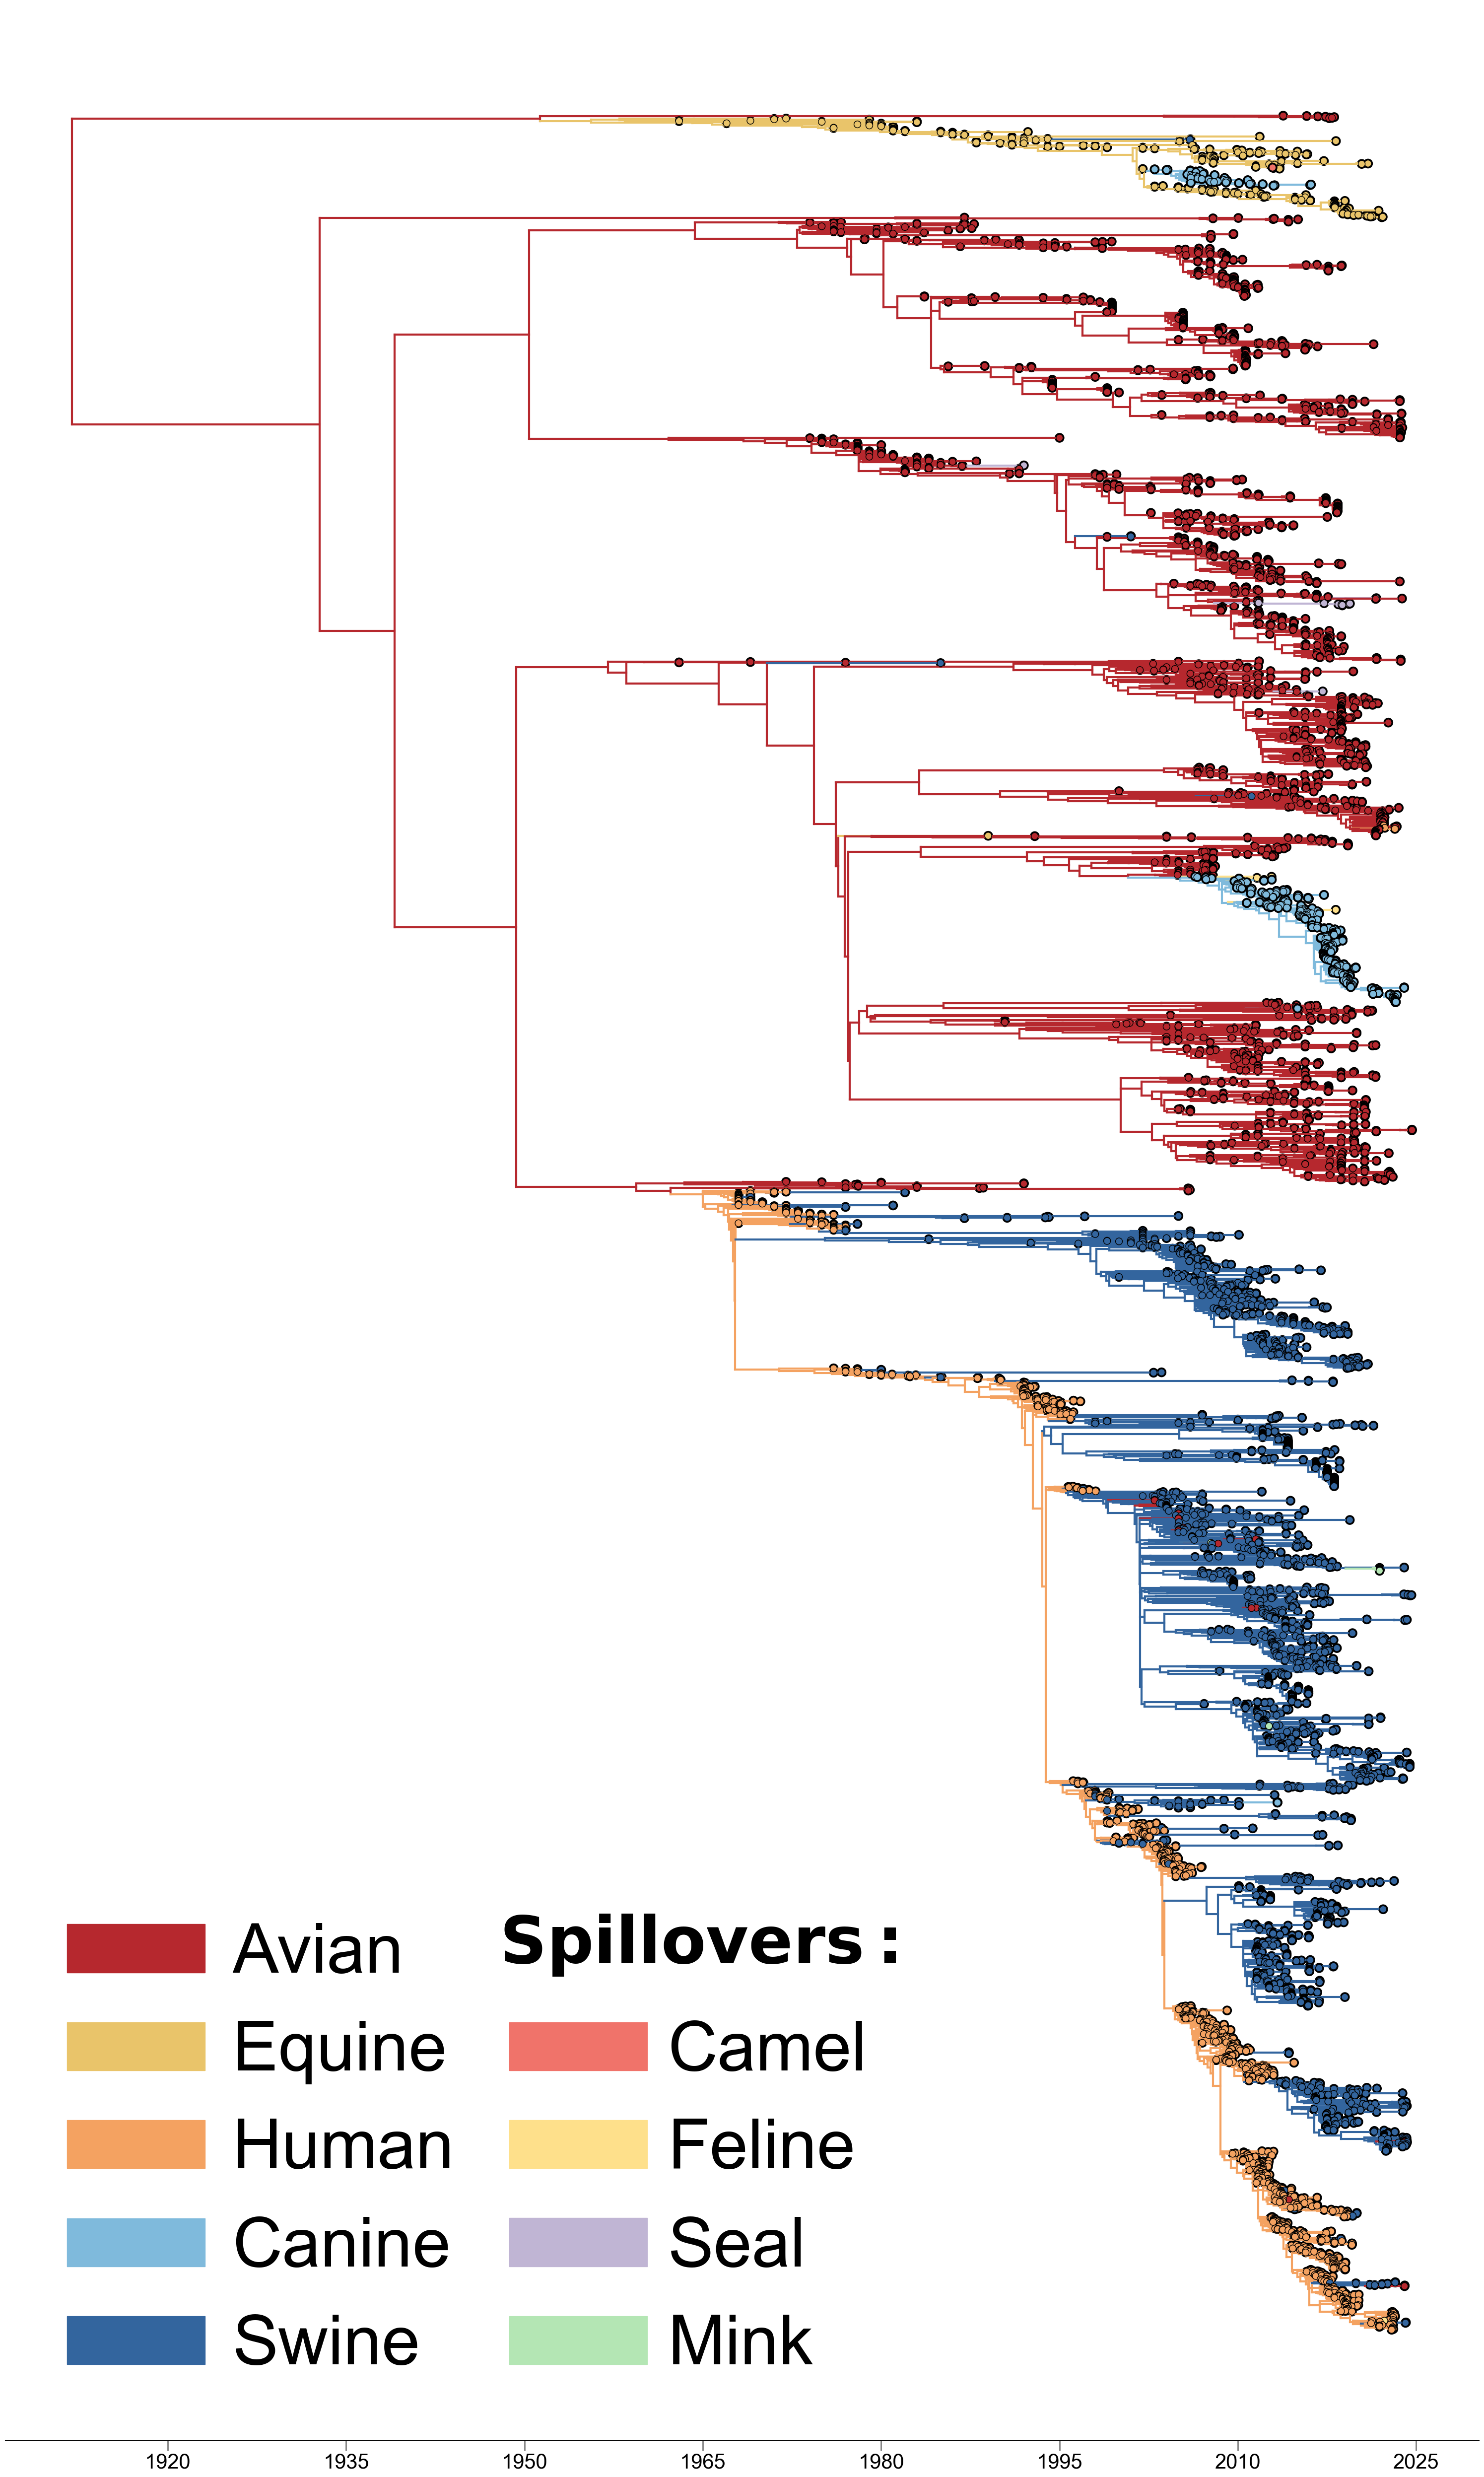

In [5]:
plot_supp(mytree)

In [6]:
# MAIN FIGURE

def plot_host(mytree):
    
    plt.rcParams["font.family"] = "Arial"

    fig, ax = plt.subplots(figsize=(20, 15))

    x_attr = lambda k: k.absoluteTime
    
    color_by = lambda k: host_colors.get(k.traits["node_attrs"]["host"]["value"])

    mytree.plotTree(ax, x_attr=x_attr, colour=color_by, width=3)
    
    def canine_func(k):
        if k.traits["node_attrs"]["host"]["value"] == "Canine":
            return 100
        else:
            return 0
        
    def camel_func(k):
        if k.traits["node_attrs"]["host"]["value"] == "Camel":
            return 100
        else:
            return 0

    def other_func(k):
        if k.traits["node_attrs"]["host"]["value"] != "Canine" or k.traits["node_attrs"]["host"]["value"] != "Equine":
            return 100
        else:
            return 0
        
    
    mytree.plotPoints(ax,
                   x_attr=x_attr,
                   size=lambda k: other_func(k),
                   colour=color_by,
                   outline_colour='black',
                   zorder=2,
                   marker='o',
                   edgecolor='black'
                     )
    
    mytree.plotPoints(ax,
                   x_attr=x_attr,
                   size=lambda k: canine_func(k),
                   colour=color_by,
                   outline_colour='black',
                   zorder=5,
                   marker='o',
                   edgecolor='black'
                     )
    
    mytree.plotPoints(ax,
                   x_attr=x_attr,
                   size=lambda k: camel_func(k),
                   colour=color_by,
                   outline_colour='black',
                   zorder=5,
                   marker='o',
                   edgecolor='black'
                     )

    # Create legend with main hosts on left, secondary on right
    main_handles = [Patch(color=color, label=host) 
                    for host, color in main_hosts_colors.items()]
    secondary_handles = [Patch(color=color, label=host) 
                         for host, color in secondary_hosts_colors.items()]
    
    # main hosts
    legend1 = ax.legend(handles=main_handles, 
                    loc="lower left", 
                    fontsize='35',
                    frameon=False)

    # secondary hosts
    legend2 = ax.legend(handles=secondary_handles,
                    loc="lower left",
                    bbox_to_anchor=(0.18, 0.0004),
                    fontsize='35',
                    frameon=False)

    ax.add_artist(legend1)

    ax.text(0.27, 0.23, "$\\bf{Spillovers:}$", fontsize=33, transform=ax.transAxes, 
            ha='center', va='bottom', weight='bold', fontfamily='Arial')
    
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    ax.set_yticks([])
    ax.set_yticklabels([])
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
    ax.tick_params(axis='x', labelsize=30, size=15, width=2, color='grey')
    
    fig.tight_layout()
     
    plt.savefig("plots/ha-time-tree.pdf")
    plt.show()

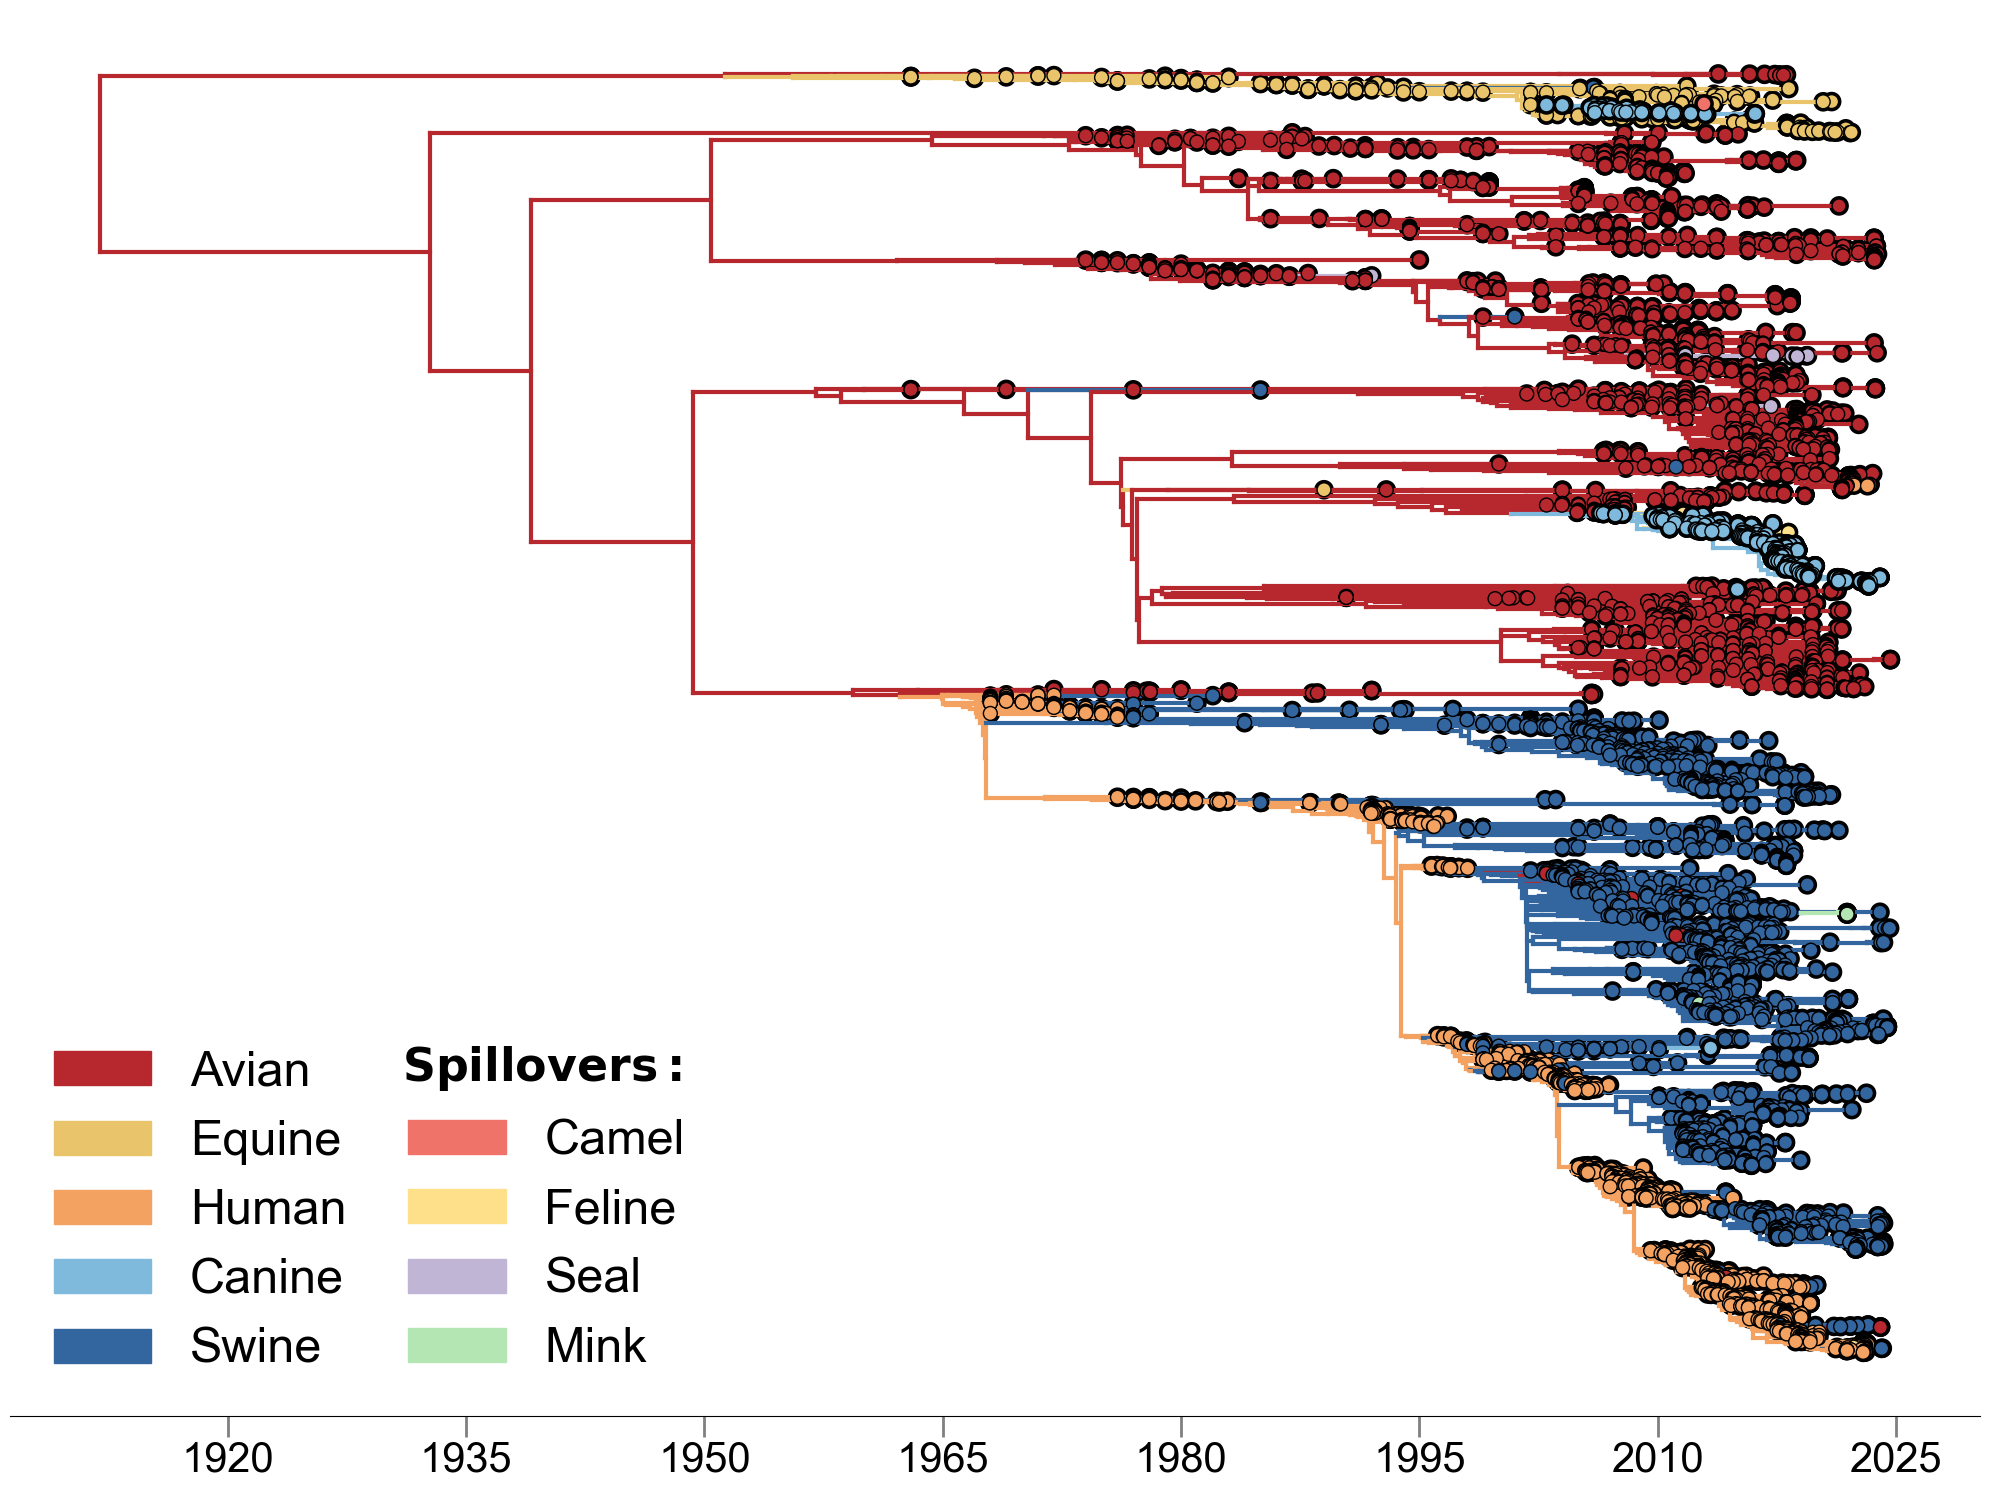

In [7]:
plot_host(mytree)